M.Talha Ramzan
---
2330-0141
---
BS AI
---
Lab 03


**1. Experiment 1 — Mean / Averaging Filter**

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

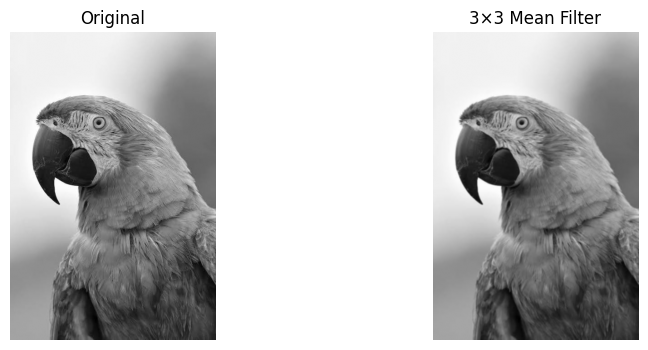

In [4]:
# Load image
image = cv2.imread("/content/images.jpg", cv2.IMREAD_GRAYSCALE)

# Check that image loaded successfully
if image is None:
    print("Image not found. Check the file path.")
else:
    # 3×3 Mean Filter
    mean_kernel = np.ones((3, 3), dtype=np.float32) / 9
    mean_filtered = cv2.filter2D(image, -1, mean_kernel)

    # Display
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mean_filtered, cmap="gray")
    plt.title("3×3 Mean Filter")
    plt.axis("off")

    plt.show()

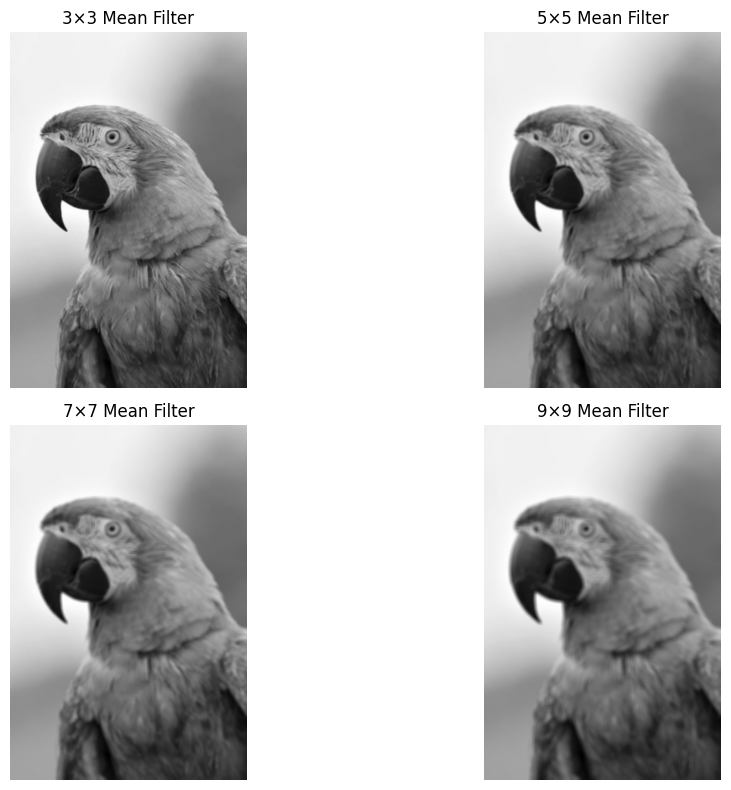

In [5]:
kernel_sizes = [3, 5, 7, 9]

plt.figure(figsize=(12, 8))

for i, size in enumerate(kernel_sizes):

    kernel = np.ones((size, size), dtype=np.float32) / (size * size)

    filtered = cv2.filter2D(image, -1, kernel)

    plt.subplot(2, 2, i + 1)
    plt.imshow(filtered, cmap="gray")
    plt.title(f"{size}×{size} Mean Filter")
    plt.axis("off")

plt.tight_layout()
plt.show()



**2. Experiment 2 — Gaussian Smoothing**

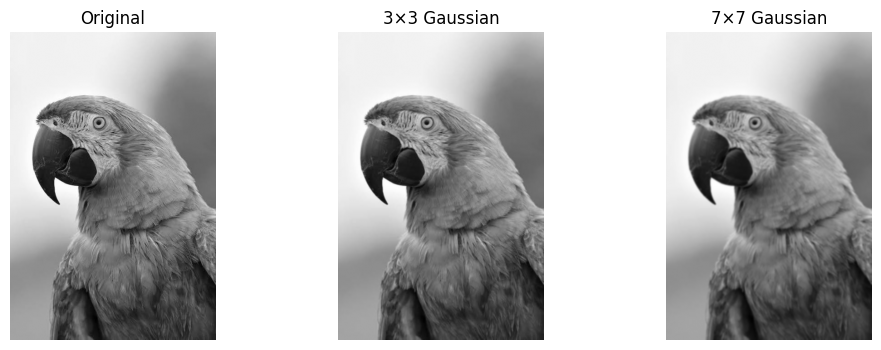

In [6]:
import cv2
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("/content/images.jpg", cv2.IMREAD_GRAYSCALE)

# Gaussian filters
gaussian_3 = cv2.GaussianBlur(image, (3, 3), sigmaX=0)
gaussian_7 = cv2.GaussianBlur(image, (7, 7), sigmaX=0)

# Display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaussian_3, cmap="gray")
plt.title("3×3 Gaussian")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gaussian_7, cmap="gray")
plt.title("7×7 Gaussian")
plt.axis("off")

plt.show()

**3. Experiment 3 — Manual Gaussian Kernel**

Gaussian Kernel:
[[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]
Kernel sum: 1.0


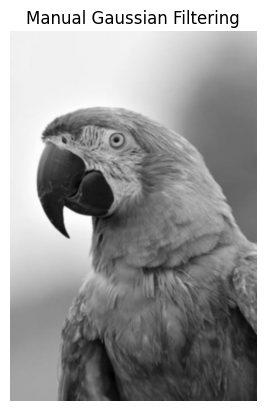

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("/content/images.jpg", cv2.IMREAD_GRAYSCALE)


def gaussian_kernel(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))

    # Normalize kernel so its sum becomes 1
    kernel = kernel / np.sum(kernel)

    return kernel


# Create 5×5 Gaussian kernel
kernel = gaussian_kernel(5, 1)

print("Gaussian Kernel:")
print(kernel)

print("Kernel sum:", kernel.sum())


# Apply manual Gaussian filtering
gaussian_manual = cv2.filter2D(image, -1, kernel)


# Display
plt.imshow(gaussian_manual, cmap="gray")
plt.title("Manual Gaussian Filtering")
plt.axis("off")
plt.show()

**4. Experiment 4 — Median Filter**

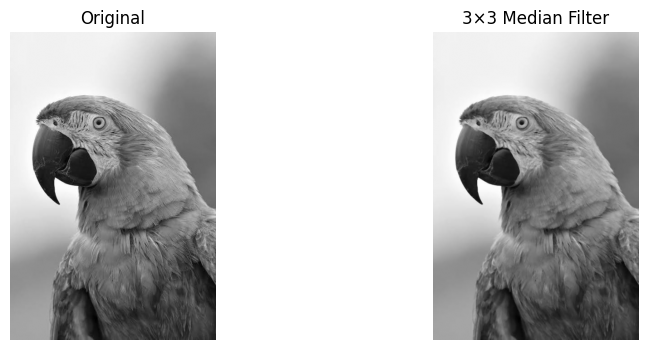

In [8]:
import cv2
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("/content/images.jpg", cv2.IMREAD_GRAYSCALE)

# Apply 3×3 Median Filter
median = cv2.medianBlur(image, 3)

# Display
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(median, cmap="gray")
plt.title("3×3 Median Filter")
plt.axis("off")

plt.show()

**5. Experiment 5 — Salt-and-Pepper Noise Removal**

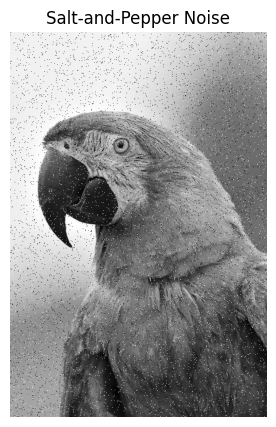

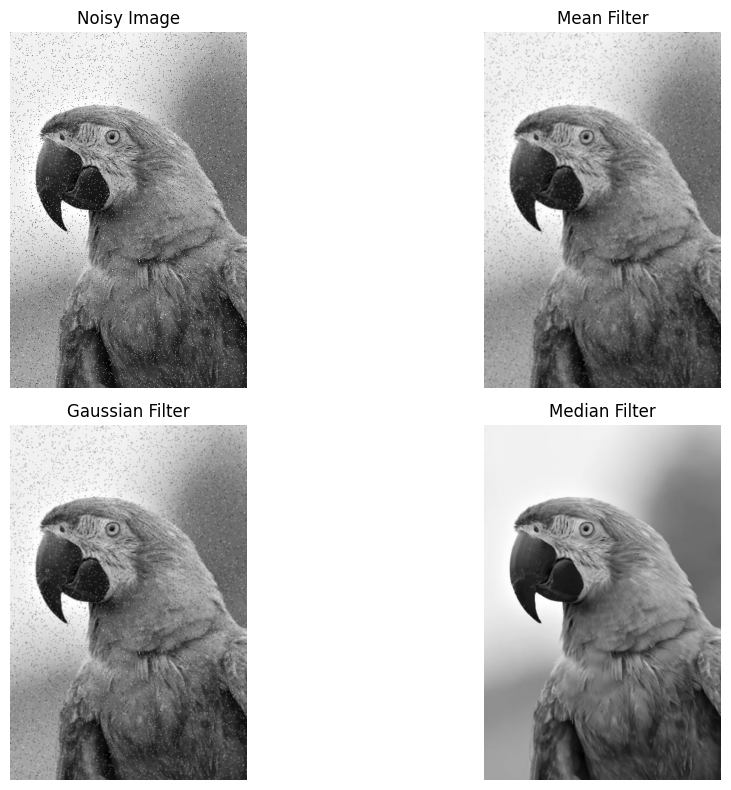

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


# Load grayscale image
image = cv2.imread("/content/images.jpg", cv2.IMREAD_GRAYSCALE)

# Check if image loaded successfully
if image is None:
    raise FileNotFoundError("Image not found. Check the image path.")


# --------------------------------------------------
# Step 1: Add Salt-and-Pepper Noise
# --------------------------------------------------

def add_salt_pepper_noise(image, amount=0.02):
    noisy = image.copy()

    # Number of pixels to make noisy
    num_pixels = int(amount * image.size)

    # Add salt noise (white pixels)
    coords = (
        np.random.randint(0, image.shape[0], num_pixels),
        np.random.randint(0, image.shape[1], num_pixels)
    )
    noisy[coords] = 255

    # Add pepper noise (black pixels)
    coords = (
        np.random.randint(0, image.shape[0], num_pixels),
        np.random.randint(0, image.shape[1], num_pixels)
    )
    noisy[coords] = 0

    return noisy


# Generate noisy image
noisy = add_salt_pepper_noise(image, amount=0.02)


# Display noisy image
plt.figure(figsize=(6, 5))
plt.imshow(noisy, cmap="gray")
plt.title("Salt-and-Pepper Noise")
plt.axis("off")
plt.show()


# --------------------------------------------------
# Step 2: Apply Mean Filter
# --------------------------------------------------

mean_noisy = cv2.blur(noisy, (3, 3))


# --------------------------------------------------
# Step 3: Apply Gaussian Filter
# --------------------------------------------------

gaussian_noisy = cv2.GaussianBlur(noisy, (3, 3), 0)


# --------------------------------------------------
# Step 4: Apply Median Filter
# --------------------------------------------------

median_noisy = cv2.medianBlur(noisy, 3)


# --------------------------------------------------
# Step 5: Compare All Filters
# --------------------------------------------------

plt.figure(figsize=(12, 8))

# Noisy image
plt.subplot(2, 2, 1)
plt.imshow(noisy, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

# Mean filter
plt.subplot(2, 2, 2)
plt.imshow(mean_noisy, cmap="gray")
plt.title("Mean Filter")
plt.axis("off")

# Gaussian filter
plt.subplot(2, 2, 3)
plt.imshow(gaussian_noisy, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

# Median filter
plt.subplot(2, 2, 4)
plt.imshow(median_noisy, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

**Question: Which filter performs best for salt-and-pepper noise?**

Median Filter salt-and-pepper noise ke liye best perform karta hai.

Why?
Salt-and-pepper noise mein kuch pixels randomly 0 (black) ya 255 (white) ho jate hain. Mean aur Gaussian filters averaging karte hain, is liye ye extreme values (0 aur 255) se affect ho jate hain aur image ko blur kar sakte hain.

Median filter neighborhood ke pixels ko sort karta hai aur middle value (median) select karta hai. Is wajah se 0 ya 255 jese outlier pixels remove ho jate hain aur edges bhi comparatively better preserve hoti hain.

**Experiment 6 — Laplacian Sharpening**

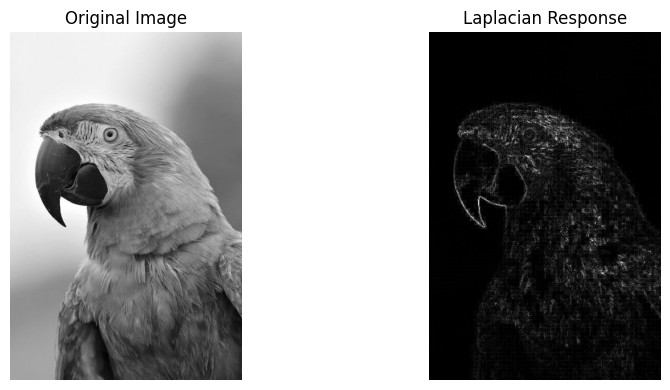

In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


# Load image
image = cv2.imread("/content/images.jpg", cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image not found. Check the image path.")


# Laplacian kernel
laplacian_kernel = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
], dtype=np.float32)


# Apply Laplacian filter
laplacian_signed = cv2.filter2D(
    image,
    cv2.CV_64F,
    laplacian_kernel
)


# Convert response to displayable image
laplacian = np.clip(
    np.abs(laplacian_signed),
    0,
    255
).astype(np.uint8)


# Display original and Laplacian response
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian Response")
plt.axis("off")

plt.tight_layout()
plt.show()

**Task 7 — Laplacian Sharpening**

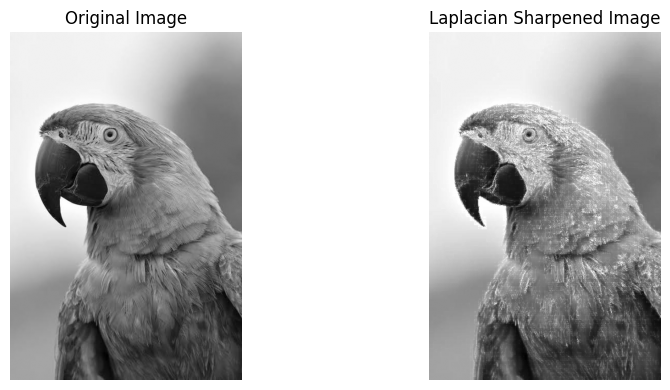

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("/content/images.jpg", cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image not found. Check the image path.")

# Laplacian kernel
laplacian_kernel = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
], dtype=np.float32)

# Apply Laplacian filter
laplacian = cv2.filter2D(
    image,
    cv2.CV_64F,
    laplacian_kernel
)

# Convert Laplacian response to uint8
laplacian = np.abs(laplacian)
laplacian = np.clip(laplacian, 0, 255).astype(np.uint8)

# Laplacian Sharpening
sharpened = cv2.addWeighted(
    image,
    1.0,
    laplacian,
    1.0,
    0
)

# Display Original and Sharpened image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened, cmap="gray")
plt.title("Laplacian Sharpened Image")
plt.axis("off")

plt.tight_layout()
plt.show()

8. Experiment 8 — Sobel Gradient Operator

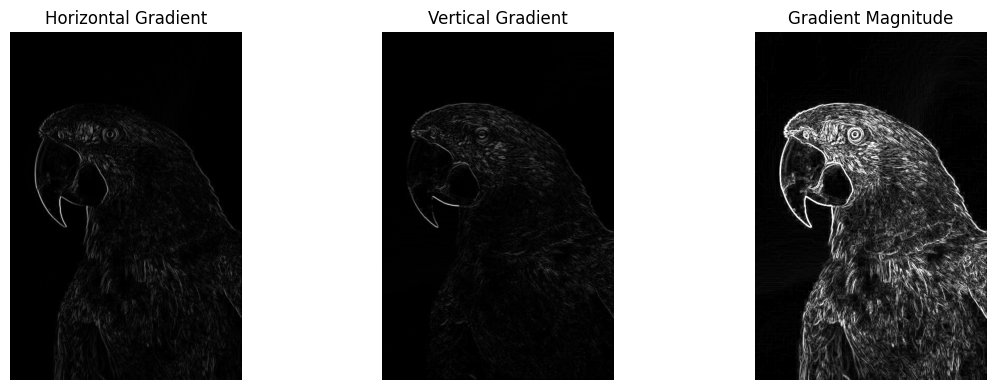

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


# Load image
image = cv2.imread(
    "/content/images.jpg",
    cv2.IMREAD_GRAYSCALE
)

if image is None:
    raise FileNotFoundError("Image not found. Check the image path.")


# Sobel X gradient
gx = cv2.Sobel(
    image,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)


# Sobel Y gradient
gy = cv2.Sobel(
    image,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)


# Gradient magnitude
magnitude = np.sqrt(gx**2 + gy**2)

# Convert to 0-255
magnitude = np.clip(
    magnitude,
    0,
    255
).astype(np.uint8)


# Display results
plt.figure(figsize=(12, 4))


# Horizontal Gradient
plt.subplot(1, 3, 1)
plt.imshow(np.abs(gx), cmap="gray")
plt.title("Horizontal Gradient")
plt.axis("off")


# Vertical Gradient
plt.subplot(1, 3, 2)
plt.imshow(np.abs(gy), cmap="gray")
plt.title("Vertical Gradient")
plt.axis("off")


# Gradient Magnitude
plt.subplot(1, 3, 3)
plt.imshow(magnitude, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")


plt.tight_layout()
plt.show()

**1. Research Paper Details**

**Title**: Adaptive Median Filters: New Algorithms and Results

**Authors**: H. Hwang and R. A. Haddad

**Journal**: IEEE Transactions on Image Processing

**Volume**: 4

**Issue**: 4

**Pages**: 499–502

**Publication**: April 1995

**DOI**: 10.1109/83.370679



⏳ Running Adaptive Median Filter (this may take a few seconds)...
✅ Filtering complete!


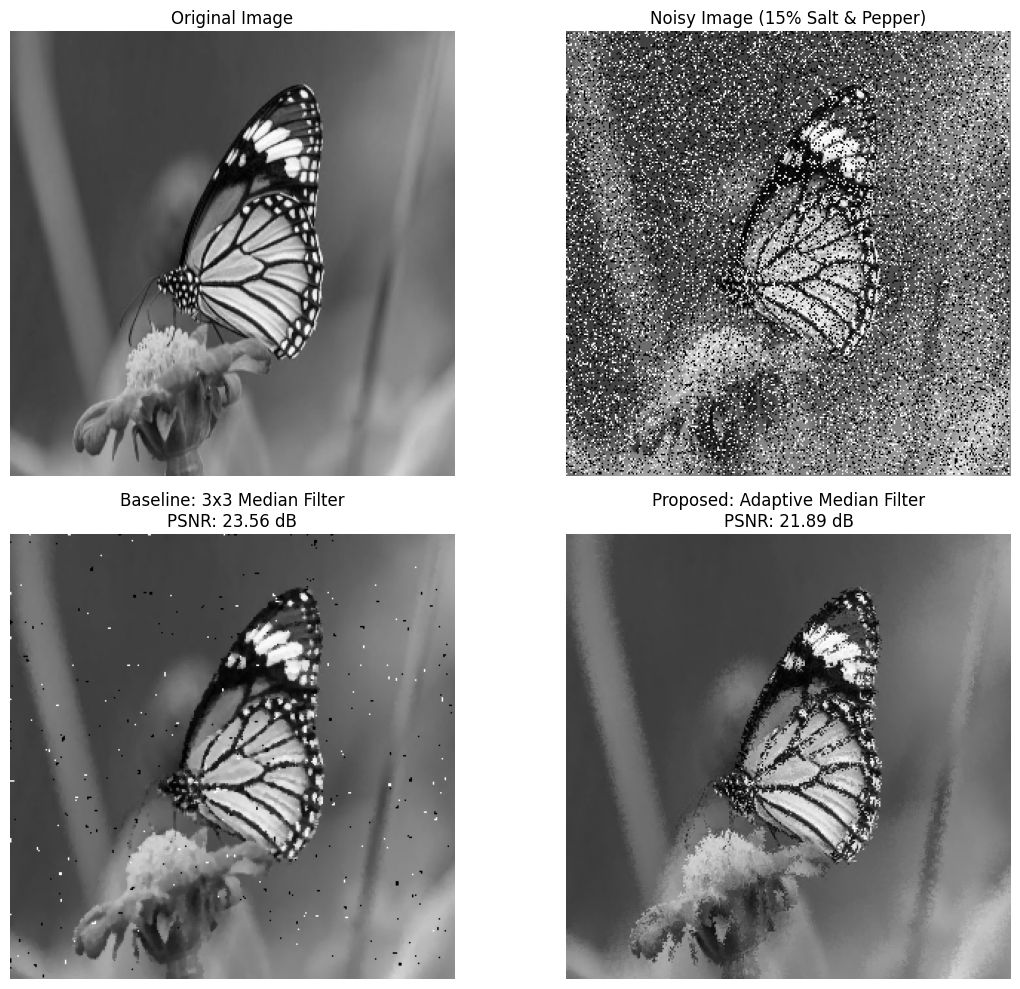

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def add_salt_pepper_noise(image, amount=0.05):
    """Adds salt and pepper noise to an image."""
    noisy = image.copy()
    num_pixels = int(amount * image.size)

    # Salt (255)
    coords = [np.random.randint(0, i - 1, num_pixels) for i in image.shape]
    noisy[tuple(coords)] = 255

    # Pepper (0)
    coords = [np.random.randint(0, i - 1, num_pixels) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

def adaptive_median_filter(img, max_window_size=7):
    """
    Implements the Adaptive Median Filter based on Hwang & Haddad (1995).
    """
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Pad the image to handle borders
    pad_size = max_window_size // 2
    img_pad = cv2.copyMakeBorder(img, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_REFLECT)
    out_img = np.copy(img)

    rows, cols = img.shape

    for y in range(rows):
        for x in range(cols):
            window_size = 3
            replaced = False

            while window_size <= max_window_size:
                half_w = window_size // 2
                # Extract neighborhood
                neighborhood = img_pad[y : y + window_size, x : x + window_size]

                z_min = np.min(neighborhood)
                z_max = np.max(neighborhood)
                z_med = np.median(neighborhood)
                z_xy = img[y, x]

                # --- Level A ---
                # Is the median a pulse (noise)?
                if (z_med > z_min) and (z_med < z_max):
                    # --- Level B ---
                    # Is the current pixel a pulse (noise)?
                    if (z_xy > z_min) and (z_xy < z_max):
                        out_img[y, x] = z_xy      # Not noise, keep original
                    else:
                        out_img[y, x] = z_med     # Is noise, replace with median
                    replaced = True
                    break # Exit while loop, move to next pixel
                else:
                    window_size += 2 # Increase window size and re-evaluate

            # Fallback if max window size is reached
            if not replaced:
                neighborhood = img_pad[y : y + max_window_size, x : x + max_window_size]
                out_img[y, x] = np.median(neighborhood)

    return out_img

def calculate_psnr(original, processed):
    """Calculates Peak Signal-to-Noise Ratio to objectively evaluate performance."""
    mse = np.mean((original.astype(np.float64) - processed.astype(np.float64)) ** 2)
    if mse == 0:
        return 100.0
    max_pixel = 255.0
    return 20 * np.log10(max_pixel / np.sqrt(mse))

# ==========================================
# MAIN EXECUTION
# ==========================================

# 1. Load the image using your provided path
image_path = '/content/images (1).jpg'

if not os.path.exists(image_path):
    print(f"❌ Error: File not found at '{image_path}'.")
    print("Please make sure the file is uploaded to the /content/ directory in Colab.")
else:
    # Read image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print("❌ Error: Could not read the image. The file might be corrupted.")
    else:
        # Resize to a manageable size (e.g., 300x300) so the adaptive filter runs quickly
        image = cv2.resize(image, (300, 300))

        # 2. Add Noise (15% density)
        noisy_img = add_salt_pepper_noise(image, amount=0.15)

        # 3. Apply Baseline (Standard 3x3 Median Filter)
        baseline_filtered = cv2.medianBlur(noisy_img, 3)

        # 4. Apply Proposed Method (Adaptive Median Filter)
        print("⏳ Running Adaptive Median Filter (this may take a few seconds)...")
        adaptive_filtered = adaptive_median_filter(noisy_img, max_window_size=7)
        print("✅ Filtering complete!")

        # 5. Calculate PSNR
        psnr_baseline = calculate_psnr(image, baseline_filtered)
        psnr_adaptive = calculate_psnr(image, adaptive_filtered)

        # 6. Visualization
        plt.figure(figsize=(12, 10))

        plt.subplot(2, 2, 1)
        plt.imshow(image, cmap="gray")
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(2, 2, 2)
        plt.imshow(noisy_img, cmap="gray")
        plt.title("Noisy Image (15% Salt & Pepper)")
        plt.axis("off")

        plt.subplot(2, 2, 3)
        plt.imshow(baseline_filtered, cmap="gray")
        plt.title(f"Baseline: 3x3 Median Filter\nPSNR: {psnr_baseline:.2f} dB")
        plt.axis("off")

        plt.subplot(2, 2, 4)
        plt.imshow(adaptive_filtered, cmap="gray")
        plt.title(f"Proposed: Adaptive Median Filter\nPSNR: {psnr_adaptive:.2f} dB")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

**Paper**: Adaptive Median Filters: New Algorithms and Results

**Authors**: H. Hwang and R. A. Haddad

**Journal**: IEEE Transactions on Image Processing

**Volume**: 4, Issue 4

**Year**: 1995

**Pages**: 499–502

**DOI**: 10.1109/83.370679
